In [1]:
import torch 
import numpy as np 
import h5py
import os
from pathlib import Path
import importlib
import IPython.display as ipd

import src.spatial_attn_lightning as binaural_lightning 
import yaml
from pytorch_lightning import Trainer, seed_everything
from corpus.swc_mono_test import SWCMonoTestSetH5Dataset

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

torch.set_float32_matmul_precision('medium')
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

%matplotlib inline
import matplotlib.pyplot as plt

In [2]:

config_path = "config/binaural_attn/word_task_v10_backbone_word_config.yaml"
# config_path = "config/binaural_attn/word_task_half_co_loc_v06.yaml"
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

config['num_workers'] = 2
config['hparas']['batch_size'] = 32
config['audio']['rep_kwargs']['rep_on_gpu'] = True
print(f"Default lr is {config['hparas']['lr']}")
# config['hparas']['lr'] = 0.000001
# print(f"Trying lr = {config['hparas']['lr']}")



Default lr is 0.0001


In [3]:
seed_everything(0)
importlib.reload(binaural_lightning)
module = binaural_lightning.BinauralAttentionModule(config)

[rank: 0] Seed set to 0


Using explicit dim specification for demeaning in audio transforms
Using BackBoneCNN
num_classes={'num_words': 800}
Model performing word task
Conv block order: LN -> Conv -> ReLU
Using dataset BinauralWordRecDataset
OptimizedModule(
  (_orig_mod): BackBoneCNN(
    (model_dict): ModuleDict(
      (norm_coch_rep): LayerNorm((2, 40, 20000), eps=1e-05, elementwise_affine=True)
      (conv_block_0): Sequential(
        (0): LayerNorm((2, 40, 20000), eps=1e-05, elementwise_affine=True)
        (1): Conv2d(2, 32, kernel_size=(2, 34), stride=(1, 1), bias=False)
        (2): ReLU()
      )
      (hann_pool_0): HannPooling2d()
      (conv_block_1): Sequential(
        (0): LayerNorm((32, 20, 4992), eps=1e-05, elementwise_affine=True)
        (1): Conv2d(32, 64, kernel_size=(2, 14), stride=(1, 1), bias=False)
        (2): ReLU()
      )
      (hann_pool_1): HannPooling2d()
      (conv_block_2): Sequential(
        (0): LayerNorm((64, 10, 1245), eps=1e-05, elementwise_affine=True)
        (1): Co

/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/torchaudio/functional/functional.py:1371: UserWarning: "kaiser_window" resampling method name is being deprecated and replaced by "sinc_interp_kaiser" in the next release. The default behavior remains unchanged.
  warnings.warn(


## Use cochleagram to develop manually computed gains 

In [4]:
stim_path = "/om/user/imgriff/datasets/human_word_rec_SWC_2024/model_eval_stim.h5"
sr = 44_100
label_type = "CV"
condition = '1-talker-english-different'
dataset = SWCMonoTestSetH5Dataset(h5_path=stim_path,
                                    eval_distractor_cond=condition,
                                    model_sr=sr,
                                    label_type=label_type)
coch_gram = module.coch_gram.cuda()

In [5]:
cue, target, distractor, word_int, dist_word_int = dataset[0]
cue_tf,_ = module.audio_transforms(cue.reshape(1,-1), None)
cue_cg, _ = module.coch_gram(cue_tf.expand(1,2,-1).cuda(), None)

target_tf,_ = module.audio_transforms(target.reshape(1,-1), None)
target_cg, _ = module.coch_gram(target_tf.expand(1,2,-1).cuda(), None)

mixture_tf, _ = module.audio_transforms(target.reshape(1,-1), distractor.reshape(1,-1))
mixture_cg, _ = module.coch_gram(mixture_tf.expand(1,2,-1).cuda(), None)

Mean feature value: 0.03355025500059128
CDF value at mean feature value: 0.42664739162380605
Scipy CDF value at mean feature value: 0.4266
Difference in CDF values: 4.7391623806070093e-05


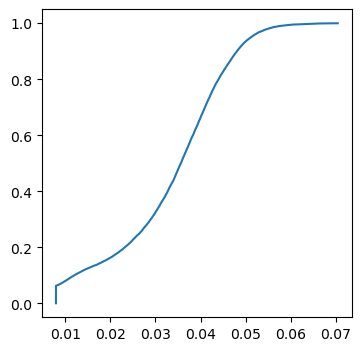

In [6]:
## Get cumulative distribution function for last dimension of cue 
from scipy.stats import ecdf

eg_feature = cue_cg[0,0,0].cpu() # time course 
time_bins = eg_feature.shape[-1]

feat_mean = eg_feature.mean().item()
feat_dist = eg_feature.sort().values
# feat_dist = torch.cat([torch.tensor([0]), feat_dist])

# plot cumulative distribution function
fig, axs = plt.subplots(1, figsize=(4, 4))
cdf =  np.linspace(1/time_bins, 1, time_bins)
axs.plot(feat_dist, cdf)

# evaluate cdf at featu_mean
cdf_val = np.interp(feat_mean, feat_dist, cdf)
print(f"Mean feature value: {feat_mean}")
print(f"CDF value at mean feature value: {cdf_val}")

## Try scipy 

res = ecdf(eg_feature.numpy())

# res.cdf.plot(axs, alpha=0.5)
scipy_cdf_val =  res.cdf.evaluate(feat_mean)
print(f"Scipy CDF value at mean feature value: {scipy_cdf_val}")
print(f"Difference in CDF values: {cdf_val - scipy_cdf_val}")

## Gains here are just emperical CDF 

In [7]:
#### Torch module 

class ECDFGains(torch.nn.Module):
    '''
    Modified from pytorch discussion
    https://discuss.pytorch.org/t/cumulative-distribution-function-of-a-tensor-cdf/64613/2 

    Compute attentional gains using Emperical CDF of unit activity over time. 
    The emperical CDF is computed by first sorting the unit activations along 
    the time dimension, and then computing the CDF of the sorted values.
    To get a scalar gain value, the CDF is then evaluated at the unit's
    average activity. 
    '''
    def __init__(self, time_bins, side='right', time_dim=-1):
        super(ECDFGains, self).__init__()

        if side.lower() not in ['right', 'left']:
            msg = "side can take the values 'right' or 'left'"
            raise ValueError(msg)
        self.side = side
        self.time_bins = time_bins
        self.time_dim = time_dim
        # INIT cumulative probabilities
        # these will be x-axis points used to interpolate the cdf
        cdf_probs = torch.linspace(1./time_bins, 1, time_bins, dtype=torch.float)
        self.register_buffer('cdf_probs', cdf_probs)

    def forward(self, cue_tensor, mixture_tensor=None):
        # sort features of the cue tensor by time
        feat_dist = cue_tensor.sort(dim=self.time_dim).values.contiguous()
        # get average activity over time per unit. keepdim for broadcasting
        feature_means = feat_dist.mean(dim=self.time_dim, keepdim=True)
        # evaluate cdf at each mean - get ixs for interpolation
        gain_ixs = torch.searchsorted(feat_dist, feature_means, side='right') - 1 
        gains = self.cdf_probs[gain_ixs]
        if mixture_tensor is None:
            return gains
        # apply gains
        attn = mixture_tensor * gains
        return attn
    



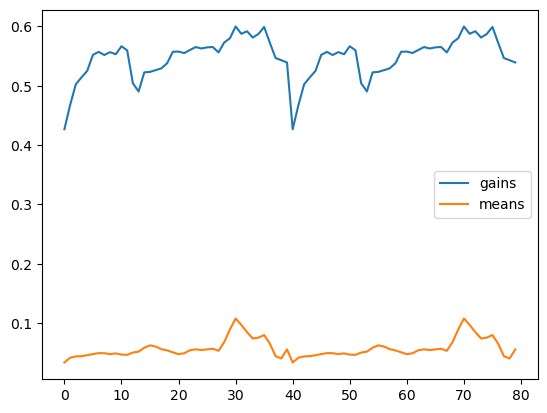

In [8]:
## Do above in torch 

time_bins = cue_cg.shape[-1]
cdf_x_axis = torch.linspace(1./time_bins, 1, time_bins)

feat_dist = cue_cg.sort(dim=-1).values.cpu()
feat_means = cue_cg.mean(dim=-1, keepdim=True).cpu()

gain_ixs = torch.searchsorted(feat_dist, feat_means, side='right') - 1 
gains = cdf_x_axis[gain_ixs]

plt.plot(gains.ravel(), label='gains')
plt.plot(feat_means.ravel(), label='means')
plt.legend()


## Test pytorch module

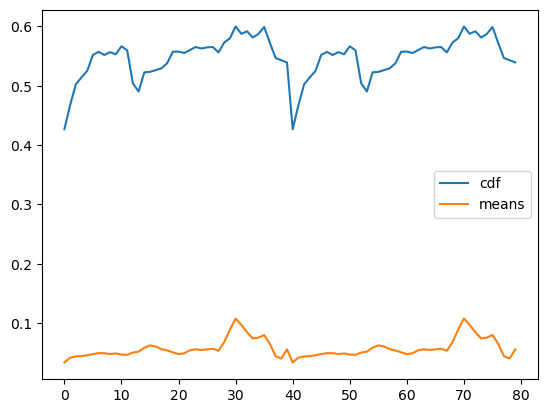

In [9]:
cdf_gain_fn = ECDFGains(time_bins).cuda()

cdf_gains = cdf_gain_fn(cue_cg)
feat_means = cue_cg.mean(dim=-1, keepdim=True)

plt.plot(cdf_gains.ravel().cpu(), label='cdf')
plt.plot(feat_means.ravel().cpu(), label='means')
plt.legend()

cdf_attention_tgt = target_cg * cdf_gains
cdf_attention_mixture = mixture_cg * cdf_gains



Text(0.5, 1.0, 'CDF Attention Mixture')

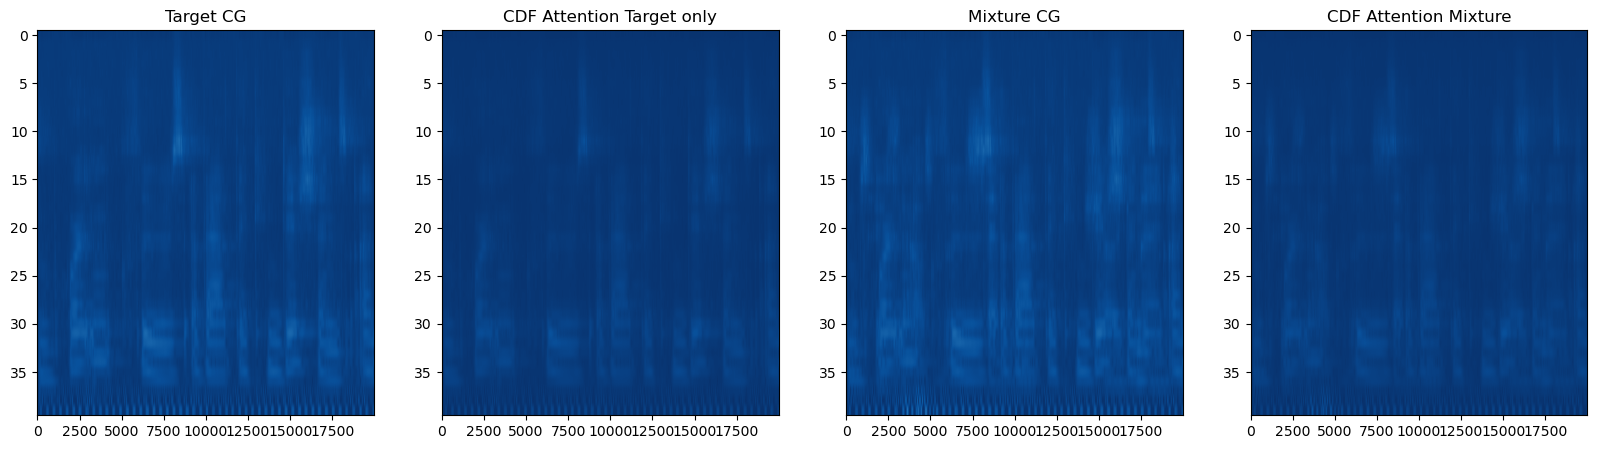

In [10]:
cmap = 'Blues_r'
fig, axs = plt.subplots(1,4, figsize=(20,5))
axs[0].imshow(target_cg[0,0].cpu().numpy(), aspect='auto', origin='upper', vmin=0, vmax=1, cmap=cmap)
axs[0].set_title('Target CG')
axs[1].imshow(cdf_attention_tgt[0,0].cpu().numpy(), aspect='auto', origin='upper', vmin=0, vmax=1, cmap=cmap)
axs[1].set_title('CDF Attention Target only')
axs[2].imshow(mixture_cg[0,0].cpu().numpy(), aspect='auto', origin='upper', vmin=0, vmax=1, cmap=cmap)
axs[2].set_title('Mixture CG')
axs[3].imshow(cdf_attention_mixture[0,0].cpu().numpy(), aspect='auto', origin='upper', vmin=0, vmax=1, cmap=cmap)
axs[3].set_title('CDF Attention Mixture')

### Dev model class that uses ECDFGains

In [11]:
import torch.nn as nn 
from collections import OrderedDict
from src.layers import conv2d_same
from src.layers import padding as pad_utils
from src.custom_modules import HannPooling2d

class BackBoneWithECDFGains(nn.Module):
    def __init__(self, input_sr, out_channels, kernel, stride, padding, pool_stride, pool_size, pool_padding, attn, dropout,
                  fc_size=512, num_classes={"num_words":800, "num_locs":504}, frequency_dim=40,
                  starting_output_len = 20000, norm_first=True, ln_affine=True, v08=False, **kwargs):
        super(BackBoneWithECDFGains, self).__init__()
        # Setup
        print(f"{num_classes=}")
        self.dual_task = False
        if isinstance(num_classes, dict):
            class_keys = num_classes.keys()
            if ("num_words" in class_keys) and not ("num_locs" in class_keys):
                # only_word 
                self.num_classes = num_classes['num_words']
                print('Model performing word task')
            elif ("num_locs" in class_keys) and not ("num_words" in class_keys):
                # only_loc
                self.num_classes = num_classes['num_locs']
                print('Model performing location task')

            elif ("num_locs" in class_keys) and ("num_words" in class_keys):
                self.dual_task = True
                self.num_words = num_classes['num_words']
                self.num_locs = num_classes['num_locs']
                print('Model performing both location and word tasks')

        self.input_sr = input_sr
        self.out_channels = out_channels
        self.kernel = kernel
        self.stride = stride
        self.padding = padding
        self.pool_stride = pool_stride
        self.pool_size = pool_size
        self.pool_padding = pool_padding
        self.frequency_dim = frequency_dim
        self.n_layers = len(out_channels)
        self.norm_first = norm_first
        if norm_first:
            print(f"Conv block order: LN -> Conv -> ReLU")
        elif not norm_first:
            print(f"Conv block order: Conv -> ReLU -> LN")

        self.input_channels = kwargs.get('input_channels', 4)
        self.ln_affine = ln_affine
        self.v08 = v08

        self.model_dict = nn.ModuleDict()
        self.output_height = frequency_dim
        self.output_len = starting_output_len # softcode eventually

        # build architecture
        coch_affine = self.ln_affine
        self.model_dict["norm_coch_rep"]= nn.LayerNorm([self.input_channels, self.frequency_dim, self.output_len], elementwise_affine=coch_affine)

        for idx in range(self.n_layers):
            nIn = self.input_channels if idx == 0 else out_channels[idx - 1]
            nOut = out_channels[idx]
            # pre-compute conv output sizes - will assign to self.output_height and self.output_len after defining block
            # Sizes will be used for normalization layers, but depend on order of norm and conv 
            # norm -> conv gets prior output shapes, conv -> norm gets new output shapes)
            # compute output shapes using conv formula [(Height + 2Pad - dilation * (kernel - 1) -1) /  Stride] + 1
            # ignoring dilation since it's not used in this model (dilation = 1)

            self.model_dict[f'attn{idx}'] = ECDFGains(self.output_len)

            if self.padding[idx] == 'same':
                output_height = self.output_height
                output_len = self.output_len
            else:
                conv_padding, _ = pad_utils.get_padding_value(self.padding[idx], self.kernel[idx], stride=self.stride[idx])
                output_height = int(np.floor((self.output_height + (2 * conv_padding[0]) - (kernel[idx][0] - 1) - 1) / stride[idx][0]) + 1)
                output_len = int(np.floor((self.output_len + (2 * conv_padding[1]) -  (kernel[idx][1] - 1) - 1) / stride[idx][1]) + 1)
    
            if self.norm_first:
                # print(f'nIn: {nIn}, nOut: {nOut}, kernel: {self.kernel[idx]}, stride: {self.stride[idx]}, padding: {self.padding[idx]}')
                # print(f"output height: {self.output_height}, output len: {self.output_len}")
                # if norm before conv, can use prior output shapes for norm layer
                block = nn.Sequential(nn.LayerNorm([nIn, self.output_height, self.output_len], elementwise_affine=self.ln_affine),
                                    conv2d_same.create_conv2d_pad(nIn, nOut, self.kernel[idx], stride=self.stride[idx], padding=self.padding[idx]),
                                    nn.ReLU())
            else:  
                # print(f'nIn: {nIn}, nOut: {nOut}, kernel: {self.kernel[idx]}, stride: {self.stride[idx]}, padding: {self.padding[idx]}')
                # print(f"output height: {output_height}, output len: {output_len}")
                # if norm after conv, use new output shapes for norm layer
                block = nn.Sequential(conv2d_same.create_conv2d_pad(nIn, nOut, self.kernel[idx], stride=self.stride[idx], padding=self.padding[idx]),
                                    nn.ReLU(),
                                    nn.LayerNorm([nOut, output_height, output_len], elementwise_affine=self.ln_affine))
            # update post-conv init
            self.output_height, self.output_len = output_height, output_len
            self.model_dict[f'conv_block_{idx}'] = block

            if self.pool_stride[idx] != -1:
                self.model_dict[f'hann_pool_{idx}'] = HannPooling2d(stride=self.pool_stride[idx], pool_size=self.pool_size[idx], padding=self.pool_padding[idx])
                # Compute output shapes for pooling layers using conv formula [(Height - Filter + 2Pad)/ Stride]+1
                self.output_height = int(np.floor((self.output_height - pool_size[idx][0] + 2 * pool_padding[idx][0]) / pool_stride[idx][0]) + 1)
                self.output_len = int(np.floor((self.output_len - pool_size[idx][1] + 2 * pool_padding[idx][1]) / pool_stride[idx][1]) + 1)
  
        self.model_dict[f'attnfc'] = ECDFGains(self.output_len)
        self.output_size = self.output_height * nOut * self.output_len
        self.fullyconnected = nn.Linear(self.output_size, fc_size)
        self.relufc = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        if self.dual_task:
            self.classificationWord = nn.Linear(fc_size, self.num_words)
            self.classificationLoc = nn.Linear(fc_size, self.num_locs)
        else:
            self.classification = nn.Linear(fc_size, self.num_classes)
    

    def forward(self, cue=None, mixture=None, cue_mask_ixs=None):
        cue = self.model_dict["norm_coch_rep"](cue)
        attn = self.model_dict["norm_coch_rep"](mixture)
        for idx in range(self.n_layers):
            attn = self.model_dict[f'attn{idx}'](cue, attn)
            cue = self.model_dict[f'conv_block_{idx}'](cue)
            attn = self.model_dict[f'conv_block_{idx}'](attn)
            # print(f"conv_block_{idx} post conv and norm mean max and min: {attn.mean().item(), attn.max().item(), attn.min().item()}")
            if self.pool_stride[idx] != -1:
                cue = self.model_dict[f'hann_pool_{idx}'](cue)
                attn = self.model_dict[f'hann_pool_{idx}'](attn)

        if self.v08 and 'attnfc' in self.model_dict.keys(): 
            attn = self.model_dict['attnfc'](cue, attn)
        out = attn
        
        out = out.view(out.size(0), self.output_size) # B x FC size
        out = self.fullyconnected(out)        
        out = self.relufc(out)
        out = self.dropout(out)  
        return self.classification(out)



In [12]:
model = BackBoneWithECDFGains(**config['model'])
model = model.cuda()
model.eval()
output = model(cue_cg, mixture_cg, None)


num_classes={'num_words': 800}
Model performing word task
Conv block order: LN -> Conv -> ReLU


In [13]:
seed_everything(0)
importlib.reload(binaural_lightning)

ckpt_path = 'attn_cue_models/word_task_v10_backbone_word_config/checkpoints/epoch=3-step=5449-v1.ckpt'
config['model']['backbone_with_ecdf_gains'] = True
module = binaural_lightning.BinauralAttentionModule.load_from_checkpoint(config=config, checkpoint_path=ckpt_path, strict=False).cuda().eval()

[rank: 0] Seed set to 0


/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/pytorch_lightning/utilities/migration/utils.py:55: The loaded checkpoint was produced with Lightning v2.5.0.post0, which is newer than your current Lightning version: v2.1.1


Using explicit dim specification for demeaning in audio transforms
Using BackBoneWithECDFGains
num_classes={'num_words': 800}
Model performing word task
Conv block order: LN -> Conv -> ReLU
Using dataset BinauralAttentionDataset
OptimizedModule(
  (_orig_mod): BackBoneWithECDFGains(
    (model_dict): ModuleDict(
      (norm_coch_rep): LayerNorm((2, 40, 20000), eps=1e-05, elementwise_affine=True)
      (attn0): ECDFGains()
      (conv_block_0): Sequential(
        (0): LayerNorm((2, 40, 20000), eps=1e-05, elementwise_affine=True)
        (1): Conv2d(2, 32, kernel_size=(2, 34), stride=(1, 1), bias=False)
        (2): ReLU()
      )
      (hann_pool_0): HannPooling2d()
      (attn1): ECDFGains()
      (conv_block_1): Sequential(
        (0): LayerNorm((32, 20, 4992), eps=1e-05, elementwise_affine=True)
        (1): Conv2d(32, 64, kernel_size=(2, 14), stride=(1, 1), bias=False)
        (2): ReLU()
      )
      (hann_pool_1): HannPooling2d()
      (attn2): ECDFGains()
      (conv_block_2):

/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/pytorch_lightning/core/saving.py:173: Found keys that are in the model state dict but not in the checkpoint: ['model._orig_mod.model_dict.attn0.cdf_probs', 'model._orig_mod.model_dict.attn1.cdf_probs', 'model._orig_mod.model_dict.attn2.cdf_probs', 'model._orig_mod.model_dict.attn3.cdf_probs', 'model._orig_mod.model_dict.attn4.cdf_probs', 'model._orig_mod.model_dict.attn5.cdf_probs', 'model._orig_mod.model_dict.attn6.cdf_probs', 'model._orig_mod.model_dict.attnfc.cdf_probs']


In [17]:
import pandas as pd
pd.read_pickle("all_stim_swc_popham_exmpt_2024_cond_manifest.pkl")

{0: {'target_harmonicity': 'harmonic', 'distractor_harmonicity': 'harmonic'},
 1: {'target_harmonicity': 'harmonic', 'distractor_harmonicity': 'inharmonic'},
 2: {'target_harmonicity': 'harmonic', 'distractor_harmonicity': 'whispered'},
 3: {'target_harmonicity': 'harmonic', 'distractor_harmonicity': None},
 4: {'target_harmonicity': 'inharmonic', 'distractor_harmonicity': 'harmonic'},
 5: {'target_harmonicity': 'inharmonic',
  'distractor_harmonicity': 'inharmonic'},
 6: {'target_harmonicity': 'inharmonic',
  'distractor_harmonicity': 'whispered'},
 7: {'target_harmonicity': 'inharmonic', 'distractor_harmonicity': None},
 8: {'target_harmonicity': 'whispered', 'distractor_harmonicity': 'harmonic'},
 9: {'target_harmonicity': 'whispered',
  'distractor_harmonicity': 'inharmonic'},
 10: {'target_harmonicity': 'whispered',
  'distractor_harmonicity': 'whispered'},
 11: {'target_harmonicity': 'whispered', 'distractor_harmonicity': None}}

In [16]:
out = module(cue_cg, mixture_cg, None)

feature distribution is contiguous: True
feature distribution is contiguous: True
feature distribution is contiguous: True
feature distribution is contiguous: True
feature distribution is contiguous: True
feature distribution is contiguous: True
feature distribution is contiguous: True
feature distribution is contiguous: True
